# GMMainPlot：LISA noise model 之前的纯 Python 绘图

本 notebook 整理自 `Mathematica/v2/GMMainPlot_v2.0.nb` 中 **LISA noise model** 之前的内容。计算仅依赖 `src/v2/gmlib.py` 和可选的 `data/*.npz` 缓存，不依赖 Mathematica notebook 或 `.m` 文件。缓存缺失时会自动执行纯 Python 数值积分并写回 `data`。

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import linear_sum_assignment

%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'src' / 'v2' / 'gmlib.py').is_file()
)
V2_SRC = PROJECT_ROOT / 'src' / 'v2'
if str(V2_SRC) not in sys.path:
    sys.path.insert(0, str(V2_SRC))

from gmlib import (
    DataRepository, GMModel, GMParameters, IntegrationSettings,
    PLANCK_TIME_S, luminosity_distance_planck, numerical_derivative,
    plot_growth_eigensystem,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'legend.frameon': False,
})
PROJECT_ROOT

PosixPath('/global/u1/l/liuyh15/WorkSpace/GM')

## 1. 参数与模型

下一个 cell 集中放置 Mathematica notebook 使用的物理参数和绘图控制参数。`q` 决定积分表缓存文件；`m1`、`alpha` 和 `mc` 在加载积分表后进入物理量计算。

In [18]:
# ===== User parameters: edit this cell =====
q = 0.99                # mass ratio m2 / m1
m1 = 40.0               # primary black-hole mass [solar masses]
alpha = 0.01             # gravitational fine-structure constant
mc = 0.1                 # cloud mass / m1

number = 100             # separation samples
x_start = 10.0           # R / r_b1
x_end = 38.0
evolution_samples = 2_000
strain_state = 0         # zero-based eigenstate index
redshift = 0.5

In [19]:
repository = DataRepository.from_project_root(PROJECT_ROOT)
parameters = GMParameters(
    mass_ratio=q,
    primary_mass_solar=m1,
    alpha=alpha,
    cloud_mass_fraction=mc,
)
cache_path = repository.model_cache_path(
    mass_ratio=q, number=number, start=x_start, end=x_end
)
model = GMModel.from_repository(
    repository,
    parameters,
    number=number,
    start=x_start,
    end=x_end,
    integration_settings=IntegrationSettings(workers=-1),
)
x = model.separation
scale = parameters.energy_scale
state_labels = [rf'$\hat{{\eta}}_{index}$' for index in range(1, 7)]
basis_labels = [
    r'$|200,1\rangle$', r'$|21{-}1,1\rangle$', r'$|211,1\rangle$',
    r'$|200,2\rangle$', r'$|21{-}1,2\rangle$', r'$|211,2\rangle$',
]

print(f'cache: {cache_path} (exists={cache_path.exists()})')
model.validation_metrics()

cache miss: computing gm_tables_v1_q0.99_n100_x10_38.npz with pure-Python integration


integrated separation 1/100: R=10
integrated separation 2/100: R=10.282828
integrated separation 3/100: R=10.565657
integrated separation 4/100: R=10.848485
integrated separation 5/100: R=11.131313
integrated separation 6/100: R=11.414141
integrated separation 7/100: R=11.69697
integrated separation 8/100: R=11.979798
integrated separation 9/100: R=12.262626
integrated separation 10/100: R=12.545455
integrated separation 11/100: R=12.828283
integrated separation 12/100: R=13.111111
integrated separation 13/100: R=13.393939
integrated separation 14/100: R=13.676768
integrated separation 15/100: R=13.959596
integrated separation 16/100: R=14.242424
integrated separation 17/100: R=14.525253
integrated separation 18/100: R=14.808081
integrated separation 19/100: R=15.090909
integrated separation 20/100: R=15.373737
integrated separation 21/100: R=15.656566
integrated separation 22/100: R=15.939394
integrated separation 23/100: R=16.222222
integrated separation 24/100: R=16.505051
integrate

{'separation_shape': (100,),
 'hamiltonian_shape': (100, 6, 6),
 'cloud_center_shape': (100, 6),
 'cloud_quadrupole_shape': (100, 6, 3, 3),
 'hamiltonian_hermiticity_max_abs': 0.0,
 'omega_lz_hermiticity_max_abs': 0.0,
 'eigen_residual_max_abs': 9.017496967800703e-16,
 'gw_frequency_squared_min': 2.882771230820292e-97,
 'gr_power_min': 2.0151830544543532e-27}

In [20]:
def plot_state_curves(ax, values, ylabel, *, yscale='linear'):
    values = np.asarray(values)
    if values.shape != (x.size, 6):
        raise ValueError(f'expected {(x.size, 6)}, received {values.shape}')
    for state, label in enumerate(state_labels):
        ax.plot(x, values[:, state], label=label)
    ax.set(xlabel=r'$R/r_{b,1}$', ylabel=ylabel, yscale=yscale)
    ax.legend(fontsize=8, ncol=2)
    return ax


def track_eigensystem(eigenvalues, eigenvectors):
    """Track states by globally maximizing adjacent eigenvector overlaps."""
    tracked_values = np.asarray(eigenvalues).copy()
    tracked_vectors = np.asarray(eigenvectors, dtype=np.complex128).copy()
    permutations = np.empty(tracked_values.shape, dtype=int)
    permutations[0] = np.arange(tracked_values.shape[1])

    for point in range(1, tracked_vectors.shape[0]):
        overlap = np.abs(
            tracked_vectors[point - 1].conj() @ tracked_vectors[point].T
        )
        previous_states, current_states = linear_sum_assignment(-overlap)
        permutation = current_states[np.argsort(previous_states)]
        permutations[point] = permutation
        tracked_values[point] = tracked_values[point, permutation]
        tracked_vectors[point] = tracked_vectors[point, permutation]

        adjacent_overlap = np.einsum(
            "ij,ij->i",
            tracked_vectors[point - 1].conj(),
            tracked_vectors[point],
        )
        phase = np.ones_like(adjacent_overlap)
        nonzero = np.abs(adjacent_overlap) > 0.0
        phase[nonzero] = np.exp(-1j * np.angle(adjacent_overlap[nonzero]))
        tracked_vectors[point] *= phase[:, None]

    return (
        tracked_values,
        np.real_if_close(tracked_vectors, tol=1_000),
        permutations,
    )



def reorder_state_axis(values, permutations):
    """Apply point-dependent state permutations to any array with state axis 1."""
    values = np.asarray(values)
    index = permutations[(slice(None), slice(None)) + (None,) * (values.ndim - 2)]
    return np.take_along_axis(values, index, axis=1)


def tracked_expectation(vectors, matrices):
    return np.real_if_close(
        np.einsum(
            "nki,nij,nkj->nk",
            vectors.conj(), matrices, vectors, optimize=True,
        ),
        tol=1_000,
    ).real


def isolated_binary_frequency_squared(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    return (
        (p.primary_mass + p.secondary_mass + p.cloud_mass)
        / (np.pi**2 * radius**3)
    )


def isolated_binary_power(model):
    p = model.parameters
    radius = model.separation * p.bohr_radius_primary
    total_mass = p.primary_mass + p.secondary_mass + p.cloud_mass
    cloud_on_primary = (
        (32.0 / 5.0)
        * (p.primary_mass + p.cloud_mass) ** 2
        * p.secondary_mass**2
        * total_mass
        / radius**5
    )
    cloud_on_secondary = (
        (32.0 / 5.0)
        * p.primary_mass**2
        * (p.secondary_mass + p.cloud_mass) ** 2
        * total_mass
        / radius**5
    )
    result = np.empty((model.separation.size, 6), dtype=np.float64)
    result[:, :3] = cloud_on_primary[:, None]
    result[:, 3:] = cloud_on_secondary[:, None]
    return result

## 2. 本征矢、本征能量与导数

这里在每对相邻分离距离上最大化本征矢总重叠，用匈牙利算法统一重排六个态，再统一各态的整体相位。这样标签跟随同一个物理态，而不是在能级交叉处跟随瞬时能量排序。

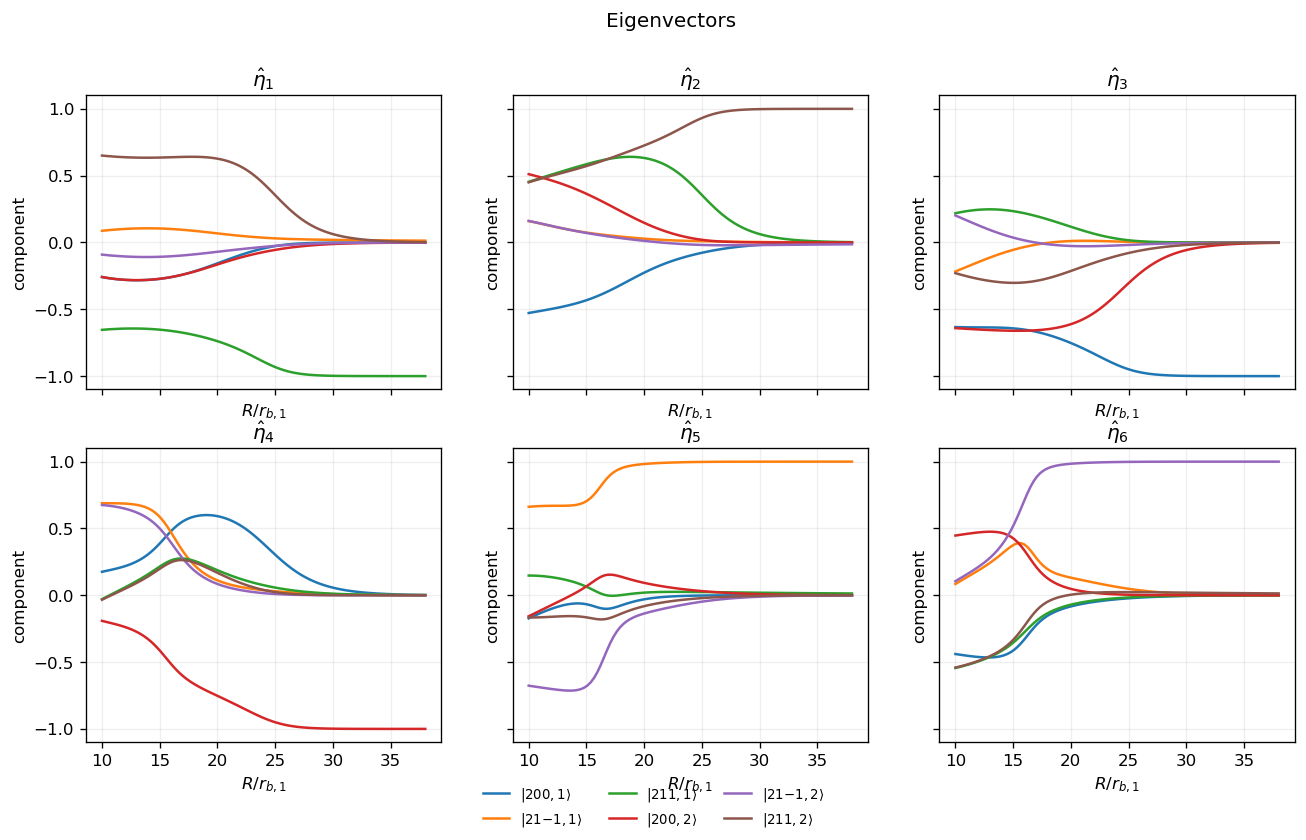

In [21]:
tracked_eigenvalues, aligned_vectors, eigenstate_permutations = track_eigensystem(
    model.eigenvalues, model.eigenvectors
)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for state, ax in enumerate(axes.flat):
    for component, label in enumerate(basis_labels):
        ax.plot(x, aligned_vectors[:, state, component], label=label)
    ax.set_title(state_labels[state])
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(r'$R/r_{b,1}$')
    ax.set_ylabel('component')
handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=8)
fig.suptitle('Eigenvectors')
plt.show()

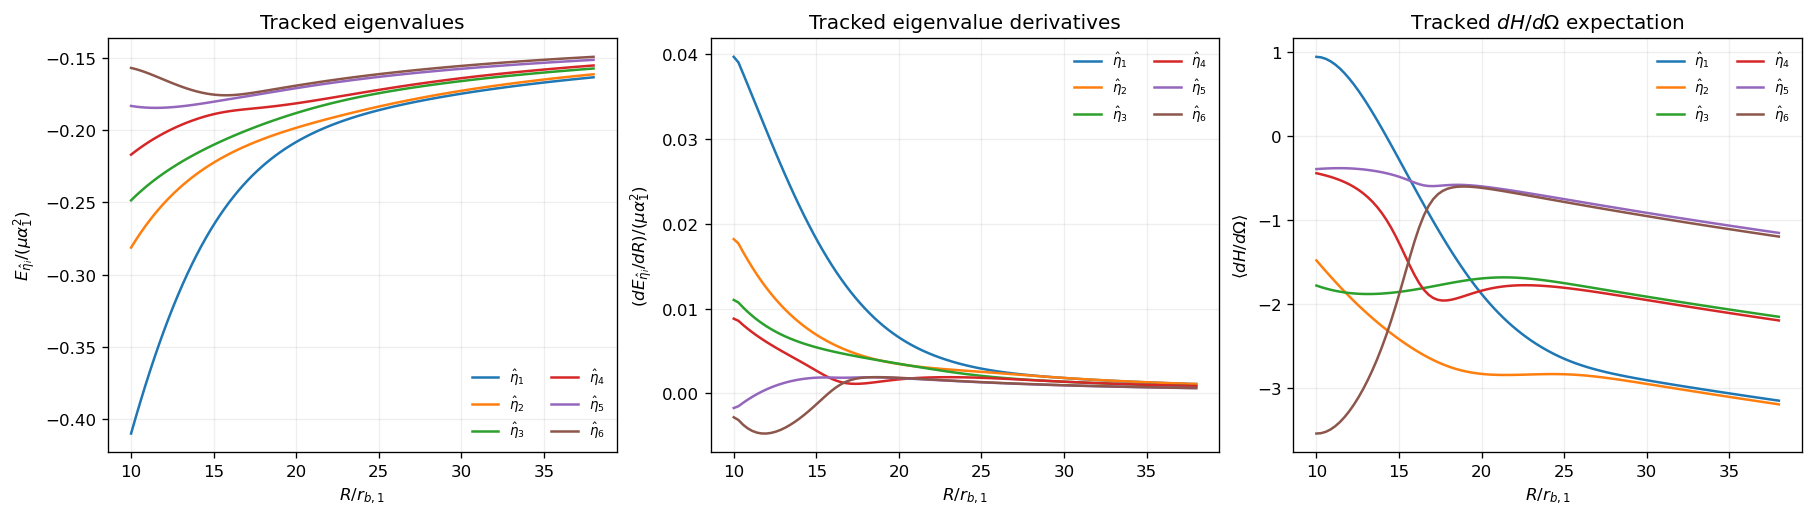

In [22]:
tracked_eigenvalue_derivatives = numerical_derivative(
    tracked_eigenvalues, x
)
tracked_dh_domega_expectation = tracked_expectation(
    aligned_vectors, model.tables.dh_domega
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], tracked_eigenvalues / scale,
    r"$E_{\hat{\eta}_i}/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[1], tracked_eigenvalue_derivatives / scale,
    r"$(dE_{\hat{\eta}_i}/dR)/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[2], tracked_dh_domega_expectation,
    r"$\langle dH/d\Omega\rangle$",
)
axes[0].set_title("Tracked eigenvalues")
axes[1].set_title("Tracked eigenvalue derivatives")
axes[2].set_title(r"Tracked $dH/d\Omega$ expectation")
plt.show()

## 3. 云质心与 GW 频率

`cloud_center` 原始表同样采用每个分离距离上的瞬时能量排序。这里使用第 2 部分得到的 `eigenstate_permutations` 重排云质心，并用跟踪后的能量导数、$\langle dH/d\Omega\rangle$ 和云质心重新计算 GW 频率。`omega0` 是把云质量视为附着在黑洞上的孤立双星参考频率。

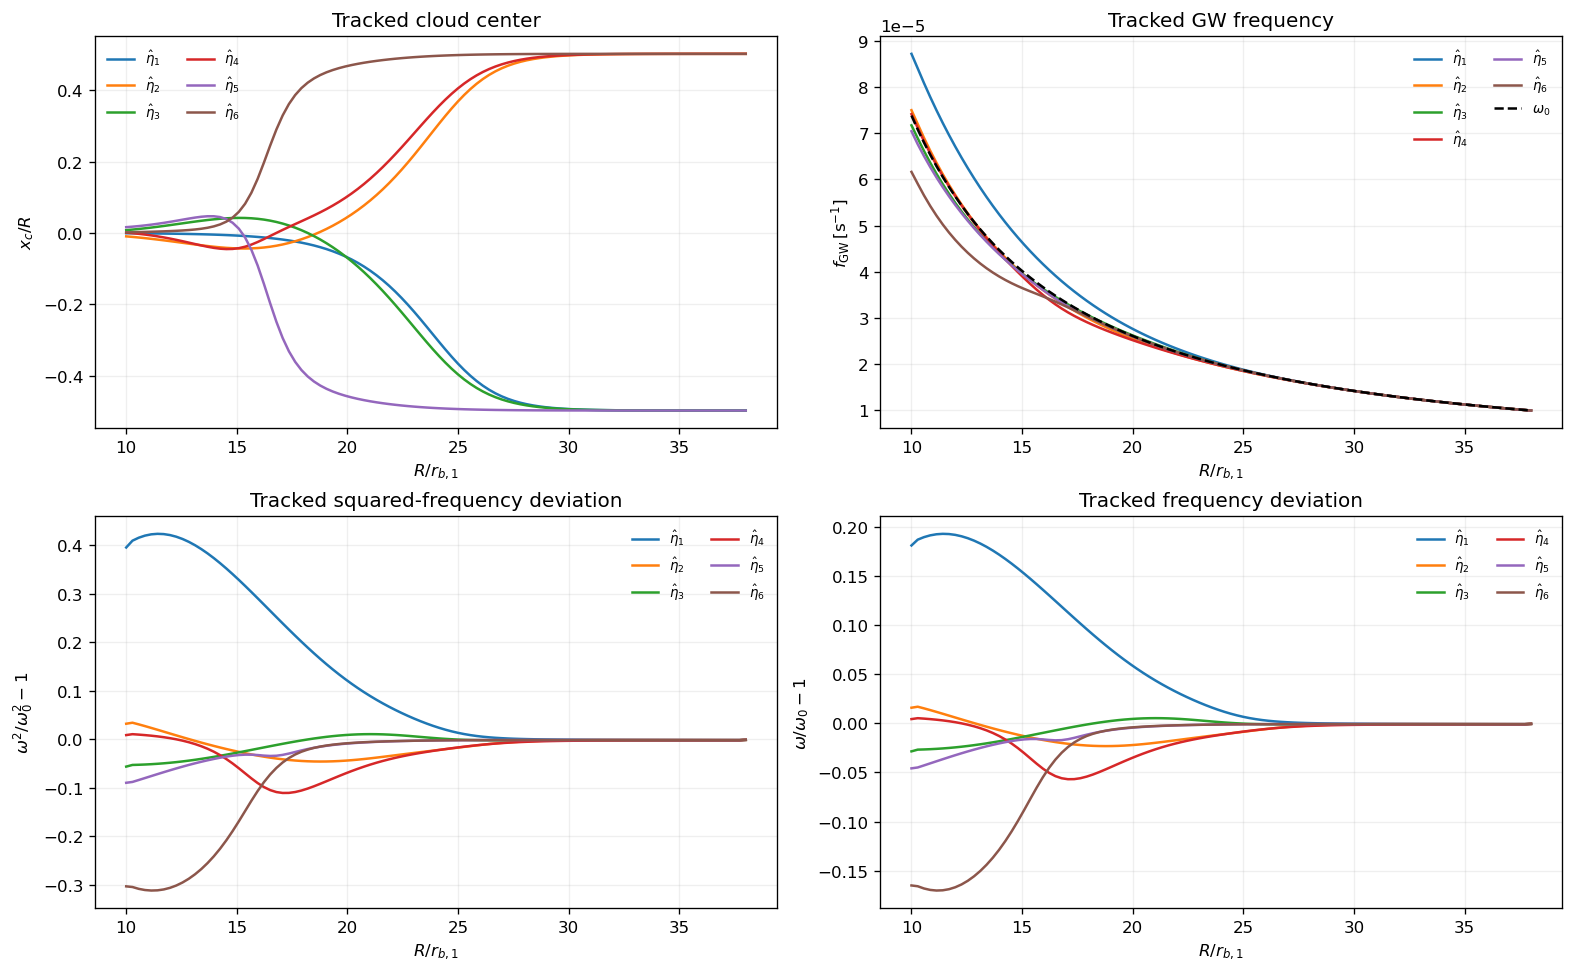

In [23]:
tracked_cloud_center = reorder_state_axis(
    model.tables.cloud_center, eigenstate_permutations
)

p = model.parameters
x_column = x[:, None]
tracked_dedr = tracked_eigenvalue_derivatives + (
    1.5
    * p.energy_scale
    * np.sqrt(1.0 + p.mass_ratio)
    * x_column ** (-1.5)
    * tracked_dh_domega_expectation
    / x_column
)
tracked_x_system = p.cloud_mass * tracked_cloud_center / (
    p.cloud_mass + p.primary_mass + p.secondary_mass
)
tracked_d1 = p.mass_ratio / (1.0 + p.mass_ratio) * x_column + tracked_x_system
tracked_d2 = 1.0 / (1.0 + p.mass_ratio) * x_column - tracked_x_system
tracked_d1_derivative = numerical_derivative(tracked_d1, x)
tracked_d2_derivative = numerical_derivative(tracked_d2, x)

tracked_frequency_squared = (
    p.primary_mass * p.secondary_mass / (x_column**2 * p.bohr_radius_primary)
    + tracked_dedr * (p.cloud_mass / p.boson_mass)
) / (
    (
        p.primary_mass * tracked_d1 * tracked_d1_derivative
        + p.secondary_mass * tracked_d2 * tracked_d2_derivative
    )
    * p.bohr_radius_primary**2
) / np.pi**2
if np.any(tracked_frequency_squared <= 0.0):
    raise FloatingPointError("computed non-positive tracked GW frequency squared")
tracked_frequency = np.sqrt(tracked_frequency_squared)

omega0_squared = isolated_binary_frequency_squared(model)
omega0 = np.sqrt(omega0_squared)
frequency_squared_deviation = tracked_frequency_squared / omega0_squared[:, None] - 1.0
frequency_deviation = tracked_frequency / omega0[:, None] - 1.0

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_state_curves(axes[0, 0], tracked_cloud_center / x[:, None], r"$x_c/R$")
plot_state_curves(
    axes[0, 1], tracked_frequency / PLANCK_TIME_S,
    r"$f_{\rm GW}\,[\mathrm{s}^{-1}]$",
)
axes[0, 1].plot(x, omega0 / PLANCK_TIME_S, "k--", label=r"$\omega_0$")
axes[0, 1].legend(fontsize=8, ncol=2)
plot_state_curves(
    axes[1, 0], frequency_squared_deviation,
    r"$\omega^2/\omega_0^2-1$",
)
plot_state_curves(
    axes[1, 1], frequency_deviation,
    r"$\omega/\omega_0-1$",
)
axes[0, 0].set_title("Tracked cloud center")
axes[0, 1].set_title("Tracked GW frequency")
axes[1, 0].set_title("Tracked squared-frequency deviation")
axes[1, 1].set_title("Tracked frequency deviation")
plt.show()

## 4. 四极矩辐射功率

原始 `cloud_quadrupole` 表和 `model.gr_power` 同样采用瞬时能量排序。这里用第 2 部分的排列重排云四极矩，并结合跟踪后的云质心与 GW 频率重新计算质量四极矩和辐射功率。参考功率分别把前三个跟踪态的云质量并入主黑洞、后三个跟踪态的云质量并入次黑洞，与 Mathematica 的 `OriginalGRPower` 定义一致。

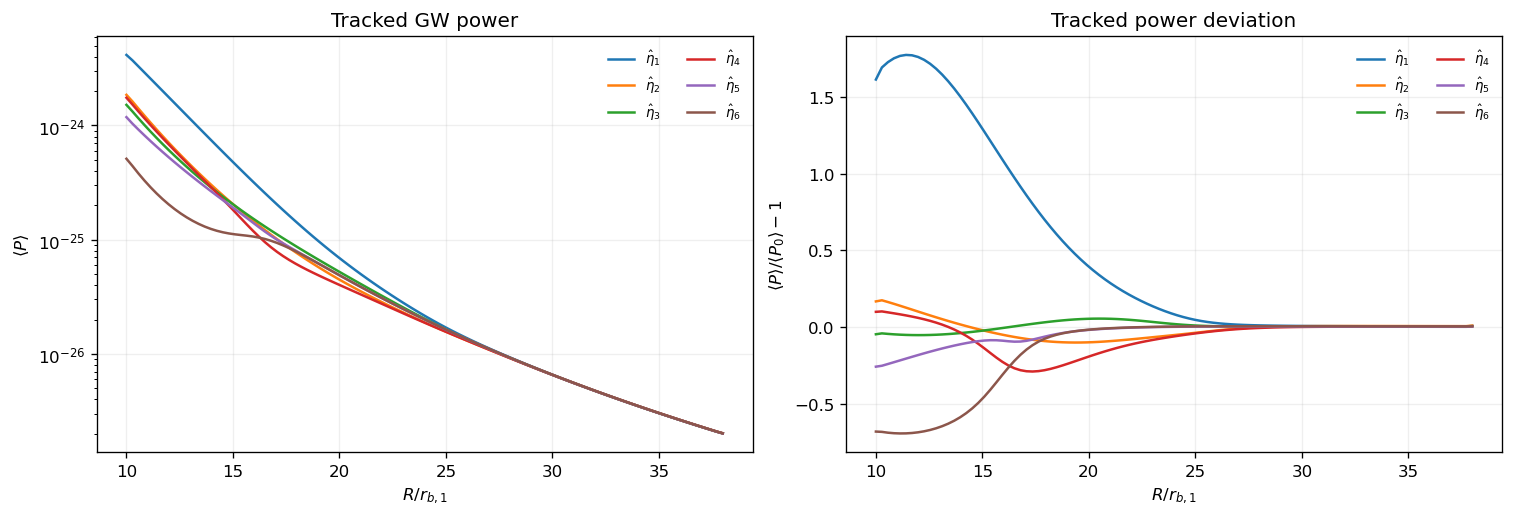

In [24]:
tracked_cloud_quadrupole = reorder_state_axis(
    model.tables.cloud_quadrupole, eigenstate_permutations
)
tracked_q_bbh = (
    p.primary_mass
    * (
        p.mass_ratio / (1.0 + p.mass_ratio) * x_column * p.bohr_radius_primary
        + tracked_x_system * p.bohr_radius_primary
    ) ** 2
    + p.secondary_mass
    * (
        1.0 / (1.0 + p.mass_ratio) * x_column * p.bohr_radius_primary
        - tracked_x_system * p.bohr_radius_primary
    ) ** 2
)
tracked_mass_quadrupole = (
    p.cloud_mass
    * tracked_cloud_quadrupole
    * p.bohr_radius_primary**2
).copy()
tracked_mass_quadrupole[:, :, 0, 0] += tracked_q_bbh

q_tensor = tracked_mass_quadrupole
tracked_power_bracket = (
    16.0 * q_tensor[:, :, 0, 0] ** 2
    + 72.0 * q_tensor[:, :, 0, 1] ** 2
    + q_tensor[:, :, 0, 2] ** 2
    + 8.0 * q_tensor[:, :, 1, 1] ** 2
    - 16.0
    * q_tensor[:, :, 0, 0]
    * (q_tensor[:, :, 0, 1] + q_tensor[:, :, 1, 1])
    + q_tensor[:, :, 1, 2] ** 2
)
tracked_gr_power = (
    (2.0 / 5.0)
    * tracked_power_bracket
    * (np.pi**2 * tracked_frequency_squared) ** 3
)

power0 = isolated_binary_power(model)
power_deviation = tracked_gr_power / power0 - 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
plot_state_curves(axes[0], tracked_gr_power, r"$\langle P\rangle$")
axes[0].set_yscale("log")
plot_state_curves(
    axes[1], power_deviation,
    r"$\langle P\rangle/\langle P_0\rangle-1$",
)
axes[0].set_title("Tracked GW power")
axes[1].set_title("Tracked power deviation")
plt.show()

In [25]:
print("power deviation at the largest separation")
print(power_deviation[-1])

power deviation at the largest separation
[0.00931299 0.01132345 0.00658503 0.00667961 0.0051658  0.00715304]


## 5. 实验室系中的云能量

实验室系修正项同样用跟踪后的本征矢求期望值，并在态重排之后计算能量的数值导数。第三幅图保留 Mathematica 中用于比较的解析参考曲线 `q(2+q) / (2 R^2 (1+q))`；对数图只显示正导数。

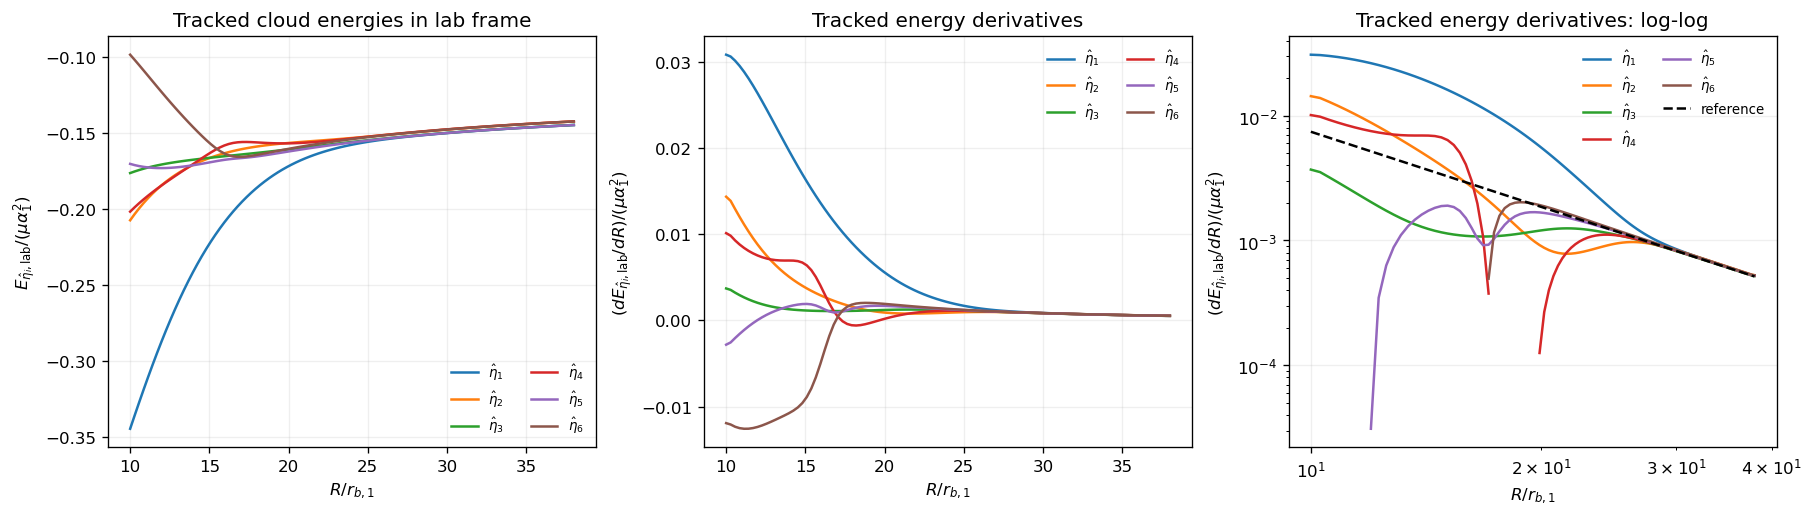

In [26]:
tracked_omega_lz_expectation = tracked_expectation(
    aligned_vectors, model.tables.omega_lz_dimless
)
tracked_cloud_energies_lab = tracked_eigenvalues + (
    tracked_omega_lz_expectation * scale
)
tracked_cloud_energy_derivatives_lab = numerical_derivative(
    tracked_cloud_energies_lab, x
)
cloud_energy = tracked_cloud_energies_lab / scale
cloud_energy_derivative = tracked_cloud_energy_derivatives_lab / scale
derivative_reference = q * (2.0 + q) / (2.0 * x**2 * (1.0 + q))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
plot_state_curves(
    axes[0], cloud_energy,
    r"$E_{\hat{\eta}_i,\rm lab}/(\mu\alpha_1^2)$",
)
plot_state_curves(
    axes[1], cloud_energy_derivative,
    r"$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$",
)
positive_derivative = np.where(
    cloud_energy_derivative > 0.0, cloud_energy_derivative, np.nan
)
plot_state_curves(
    axes[2], positive_derivative,
    r"$(dE_{\hat{\eta}_i,\rm lab}/dR)/(\mu\alpha_1^2)$",
    yscale="log",
)
axes[2].plot(x, derivative_reference, "k--", label="reference")
axes[2].set_xscale("log")
axes[2].legend(fontsize=8, ncol=2)
axes[0].set_title("Tracked cloud energies in lab frame")
axes[1].set_title("Tracked energy derivatives")
axes[2].set_title("Tracked energy derivatives: log-log")
plt.show()

## 6. 六个跟踪本征态的轨道演化与 chirp mass

先用跟踪后的云能量、云质心、GW 频率和功率构造系统总能量，再把这些连续分支注入一个 `GMModel` 实例供 `evolve` 使用。对每个态求解 `dE/dR * dR/dt = -P_GW`；若稳定分支内部出现 `dE/dR = 0`，演化会在奇点之前停止。

In [27]:
tracked_rho1 = p.mass_ratio / (1.0 + p.mass_ratio) * x_column
tracked_rho2 = 1.0 / (1.0 + p.mass_ratio) * x_column
tracked_system_center = (
    p.cloud_mass * tracked_cloud_center
    - p.primary_mass * tracked_rho1
    + p.secondary_mass * tracked_rho2
) / (p.cloud_mass + p.primary_mass + p.secondary_mass)
tracked_system_d1 = (
    p.mass_ratio / (1.0 + p.mass_ratio) * x_column + tracked_system_center
)
tracked_system_d2 = (
    1.0 / (1.0 + p.mass_ratio) * x_column - tracked_system_center
)
tracked_system_energies_lab = (
    (p.cloud_mass / p.boson_mass) * tracked_cloud_energies_lab
    - p.primary_mass * p.secondary_mass
    / (x_column * p.bohr_radius_primary)
    + 0.5 * p.primary_mass * (np.pi**2 * tracked_frequency_squared)
    * (tracked_system_d1 * p.bohr_radius_primary) ** 2
    + 0.5 * p.secondary_mass * (np.pi**2 * tracked_frequency_squared)
    * (tracked_system_d2 * p.bohr_radius_primary) ** 2
)

# Seed cached observables so GMModel.evolve operates entirely on tracked branches.
tracked_model = GMModel(parameters, model.tables)
tracked_model.__dict__.update({
    "eigenvalues": tracked_eigenvalues,
    "eigenvectors": aligned_vectors,
    "eigenvalue_derivatives": tracked_eigenvalue_derivatives,
    "dh_domega_expectation": tracked_dh_domega_expectation,
    "gw_frequency_squared": tracked_frequency_squared,
    "gw_frequency": tracked_frequency,
    "mass_quadrupole": tracked_mass_quadrupole,
    "gr_power": tracked_gr_power,
    "cloud_energies_lab": tracked_cloud_energies_lab,
    "cloud_energy_derivatives_lab": tracked_cloud_energy_derivatives_lab,
    "system_energies_lab": tracked_system_energies_lab,
})

evolutions = [
    tracked_model.evolve(state=state, samples=evolution_samples)
    for state in range(6)
]
[(item.state, item.time_years[-1], item.separation[-1]) for item in evolutions]

[(0, np.float64(920874652.9849811), np.float64(10.282828282828236)),
 (1, np.float64(1083055507.6392715), np.float64(10.282828282828243)),
 (2, np.float64(1031925253.2394129), np.float64(10.282828282828357)),
 (3, np.float64(1124277765.7302752), np.float64(10.282828282828238)),
 (4, np.float64(1058329662.1515952), np.float64(10.282828282828273)),
 (5, np.float64(1129292464.5671213), np.float64(10.282828282828268))]

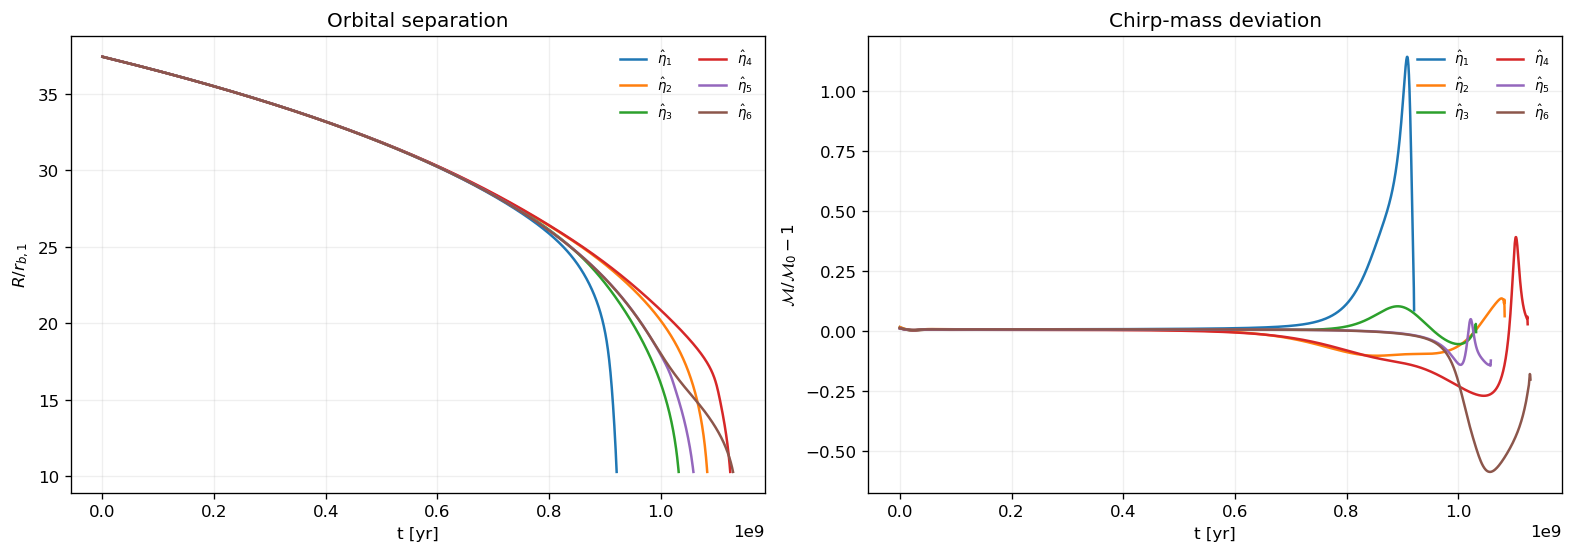

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for evolution, label in zip(evolutions, state_labels):
    axes[0].plot(evolution.time_years, evolution.separation, label=label)
    axes[1].plot(evolution.time_years, evolution.chirp_deviation, label=label)
axes[0].set(xlabel='t [yr]', ylabel=r'$R/r_{b,1}$', title='Orbital separation')
axes[1].set(
    xlabel='t [yr]',
    ylabel=r'$\mathcal{M}/\mathcal{M}_0-1$',
    title='Chirp-mass deviation',
)
for ax in axes:
    ax.legend(fontsize=8, ncol=2)
plt.show()

In [29]:
print('Eigenvector 1 chirp-mass min deviation:')
print(np.min(evolutions[0].chirp_deviation))

Eigenvector 1 chirp-mass min deviation:
0.002140749086768645


## 7. 加入超辐射增长宽度的非厄米本征系统

非厄米矩阵的本征值也会在每个分离距离独立排序。这里对复本征矢再次使用相邻最大重叠跟踪，使实部能量和虚部增长/衰减宽度共享连续的态标签。

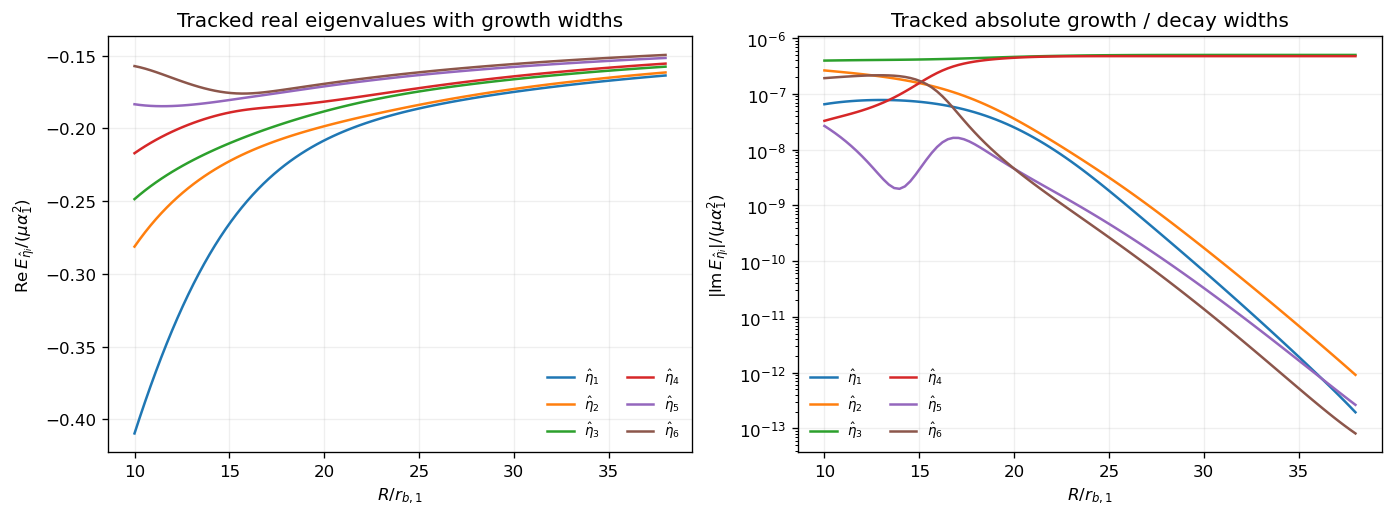

In [30]:
growth_values, growth_vectors = model.eigensystem_with_growth(
    spin_primary=1.0, spin_secondary=1.0
)
tracked_growth_values, tracked_growth_vectors, growth_permutations = (
    track_eigensystem(growth_values, growth_vectors)
)
tracked_growth_values = tracked_growth_values / scale

fig, growth_axes = plt.subplots(
    1, 2, figsize=(11.5, 4.2), constrained_layout=True
)
for state, label in enumerate(state_labels):
    growth_axes[0].plot(x, tracked_growth_values[:, state].real, label=label)
    growth_axes[1].plot(
        x, np.abs(tracked_growth_values[:, state].imag), label=label
    )
growth_axes[0].set(
    xlabel=r"$R/r_{b,1}$",
    ylabel=r"$\mathrm{Re}\,E_{\hat{\eta}_i}/(\mu\alpha_1^2)$",
    title="Tracked real eigenvalues with growth widths",
)
growth_axes[1].set(
    xlabel=r"$R/r_{b,1}$",
    ylabel=r"$|\mathrm{Im}\,E_{\hat{\eta}_i}|/(\mu\alpha_1^2)$",
    yscale="log",
    title="Tracked absolute growth / decay widths",
)
for ax in growth_axes:
    ax.legend(fontsize=8, ncol=2)
plt.show()

## 8. LISA noise model 之前的信号特征应变

这里复现原 notebook 在分界前定义的 `dE/df`、GM 特征应变、孤立 BBH 特征应变和单频振幅。所选 `strain_state` 使用跟踪后的 GW 频率和系统总能量，因此不会在能级交叉处切换物理态。

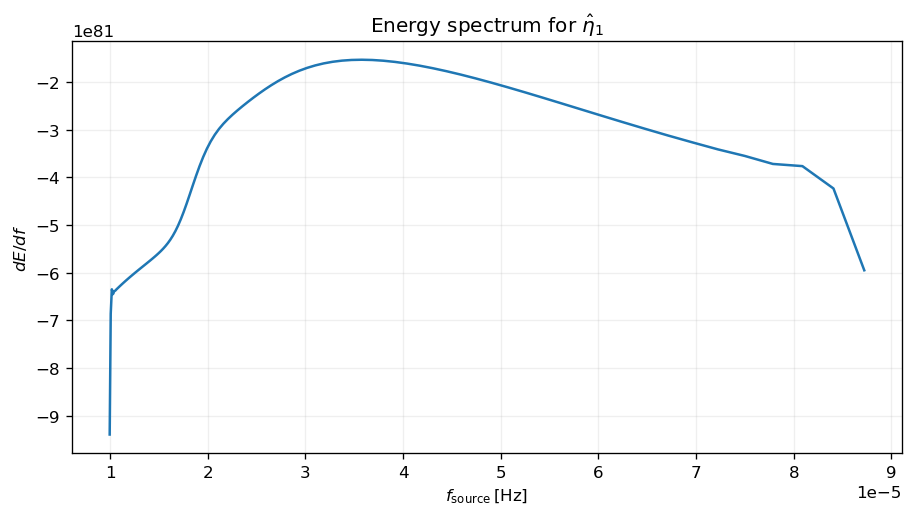

In [31]:
if strain_state not in range(6):
    raise ValueError('strain_state must be in range(6)')

frequency_planck = tracked_frequency[:, strain_state]
system_energy = tracked_system_energies_lab[:, strain_state]
energy_spline = CubicSpline(x, system_energy)
frequency_spline = CubicSpline(x, frequency_planck)
denergy_dfrequency = energy_spline.derivative()(x) / frequency_spline.derivative()(x)

# Build dE/df as a single-valued interpolation on the sampled frequency branch.
order = np.argsort(frequency_planck)
sorted_frequency, unique_indices = np.unique(frequency_planck[order], return_index=True)
sorted_denergy_dfrequency = denergy_dfrequency[order][unique_indices]
denergy_dfrequency_spline = CubicSpline(sorted_frequency, sorted_denergy_dfrequency)

source_frequency_hz = sorted_frequency / PLANCK_TIME_S
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(source_frequency_hz, sorted_denergy_dfrequency)
ax.set(xlabel=r'$f_{\rm source}\,[\mathrm{Hz}]$', ylabel=r'$dE/df$')
ax.set_title(rf'Energy spectrum for {state_labels[strain_state]}')
plt.show()

detector_frequency_hz = np.linspace(
    source_frequency_hz[0] / (1.0 + redshift),
    source_frequency_hz[-1] / (1.0 + redshift),
    800,
)
source_frequency_planck = (
    (1.0 + redshift) * detector_frequency_hz * PLANCK_TIME_S
)
distance = luminosity_distance_planck(redshift)
minus_denergy_dfrequency = -denergy_dfrequency_spline(source_frequency_planck)
if np.any(minus_denergy_dfrequency <= 0.0):
    raise FloatingPointError('-dE/df must remain positive on the selected branch')

hc_gm = np.sqrt(
    2.0 * (1.0 + redshift) ** 2
    / (np.pi**2 * distance**2)
    * minus_denergy_dfrequency
)
chirp_mass = (
    (parameters.primary_mass * parameters.secondary_mass) ** (3.0 / 5.0)
    / (parameters.primary_mass + parameters.secondary_mass) ** (1.0 / 5.0)
)
hc_bbh = np.sqrt(
    2.0 / (np.pi**2 * distance**2)
    * np.pi ** (2.0 / 3.0) / 3.0
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (detector_frequency_hz * PLANCK_TIME_S) ** (-1.0 / 3.0)
)
monochromatic_amplitude = (
    4.0 / distance
    * ((1.0 + redshift) * chirp_mass) ** (5.0 / 3.0)
    * (np.pi * PLANCK_TIME_S * detector_frequency_hz) ** (2.0 / 3.0)
)

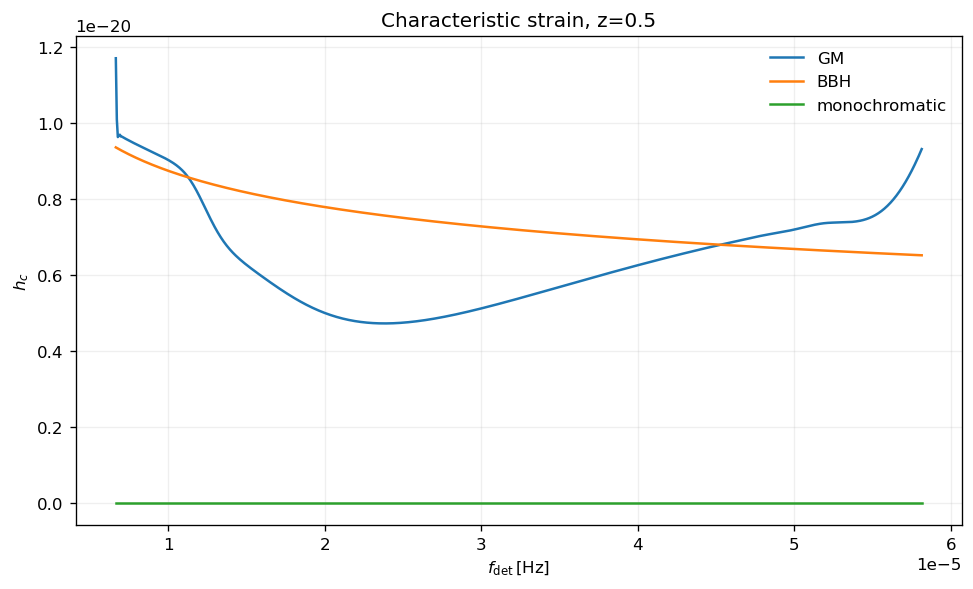

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
ax.plot(detector_frequency_hz, hc_gm, label='GM')
ax.plot(detector_frequency_hz, hc_bbh, label='BBH')
ax.plot(detector_frequency_hz, monochromatic_amplitude, label='monochromatic')
ax.set(xlabel=r'$f_{\rm det}\,[\mathrm{Hz}]$', ylabel=r'$h_c$')
ax.set_title(f'Characteristic strain, z={redshift:g}')
ax.legend()
plt.show()

## 结束位置

以上即 `GMMainPlot_v2.0.nb` 中 **LISA noise model** 标题之前的可计算内容。Mathematica 文件中误存为 Input 的压缩静态图没有复制；其对应的物理曲线已由上面的 Python cell 重新生成。